In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [277]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

In [278]:
print("Columns: ", df.columns)
print("Shape: ", df.shape)
print("Duplicates Count: ", df.duplicated().sum())
print("Null Values: ", df.isnull().sum().sum())
print("Head: ")
df.head()

Columns:  Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Shape:  (891, 12)
Duplicates Count:  0
Null Values:  866
Head: 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [279]:
df = df.drop(columns=['PassengerId', 'Ticket', 'Name', 'Cabin'], axis = 1)
print("Shape: ", df.shape)

Shape:  (891, 8)


In [280]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Null Values: ", df.isnull().sum().sum())

Null Values:  0


In [281]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [282]:
X, Y = df.drop(columns=['Survived'], axis=1), df['Survived']

In [283]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [284]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, stratify=Y, random_state=42)

In [285]:
lr1 = LogisticRegression(C = 0.1, penalty='l2', solver='liblinear', max_iter=1000, random_state=42)
lr1.fit(X_train, Y_train)
y_pred = lr1.predict(X_test)
print("Predictions: ", y_pred)

Predictions:  [0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]


In [286]:
print("Accuracy: ", metrics.accuracy_score(Y_test, y_pred))
print("Precision: ", metrics.precision_score(Y_test, y_pred))
print("Recall: ", metrics.recall_score(Y_test, y_pred))
print("F1 Score: ", metrics.f1_score(Y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(Y_test, y_pred))

Accuracy:  0.7877094972067039
Precision:  0.7540983606557377
Recall:  0.6666666666666666
F1 Score:  0.7076923076923077
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [287]:
cm = metrics.confusion_matrix(Y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[95 15]
 [23 46]]


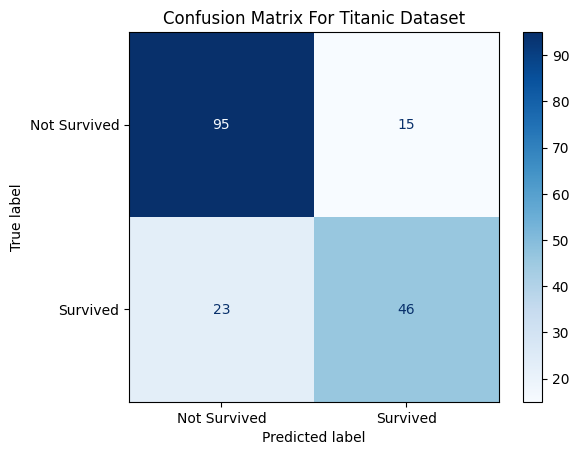

In [288]:
metrics.ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived']).plot(cmap='Blues')
plt.title("Confusion Matrix For Titanic Dataset")
plt.show()
plt.close()

In [289]:
lr2 = LogisticRegression(C = 0.1, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr2.fit(X_train, Y_train)
y_pred = lr2.predict(X_test)
print("Predictions: ", y_pred)
print("Accuracy: ", metrics.accuracy_score(Y_test, y_pred))
metrics.confusion_matrix(Y_test, y_pred)

Predictions:  [0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]
Accuracy:  0.7932960893854749


array([[96, 14],
       [23, 46]])